In [1]:
import os
import gc
import glob

from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, to_tree

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap

from pycirclize import Circos
from pycirclize.utils import ColorCycler

import seaborn as sns

import anndata as ad
import scanpy as sc

%matplotlib inline

In [2]:
## Read In Data ##

adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_annotated_w_celltypist_scanvi.h5ad')

## Toss Stressed Glia & Doublets ##

adata = adata[~(adata.obs['subclass_annotations'] == 'Stressed Glia') & ~adata.obs['pred_dbl']].copy()
gc.collect()

# Note Stressed Glia is not large enough for statistical testing, 
#adata[adata.obs['subclass_annotations'] == 'Stressed Glia'].shape[0]
# 858 # despite contribution from multiple donors, manuscripts but dominated by Walsh/Studer MEL-1 line

3527

In [3]:
## Refrorm Categories as Str For Proper Coloring ##

adata.obs['subclass_annotations'] = adata.obs['subclass_annotations'].astype('str')
adata.obs['subclass_annotations_markers'] = adata.obs['subclass_annotations_markers'].astype('str')
adata.obs['subtype_cluster_annotations'] = adata.obs['subtype_cluster_annotations'].astype('str')
adata.obs['subtype_cluster_annotations_markers'] = adata.obs['subtype_cluster_annotations_markers'].astype('str')

In [4]:
## Correct CP / Choroid Plexus Distinction ##

adata.obs['subtype_cluster_annotations'] = adata.obs['subtype_cluster_annotations'].str.replace('Choroid Plexus ', 'CP-')
adata.obs['subtype_cluster_annotations_markers'] = adata.obs['subtype_cluster_annotations_markers'].str.replace('Choroid Plexus ', 'CP-')

In [5]:
subclass_markers_order = ['Proliferative Radial Glia SOX2+HES6+TOP2A+', 'Radial Glia SOX2+PAX6+FABP7+', 
                          'Radial Glia SOX2+VIM+FABP7+', 'Hindbrain Neurons NR2F2+PBX3+LHX1+', 'Mixed Neurons FGF12+GRIN2B+CAMK2B+', 
                          'GABAergic GAD1+GAD2+CALB2+', 'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+',
                          'Mesenchymal-like cells VIM+VCAN+SPARC+']

# Make the 'subclass_annotations_markers' column a categorical type with the custom order
adata.obs['subclass_annotations_markers'] = pd.Categorical(adata.obs['subclass_annotations_markers'], 
                                                           categories=subclass_markers_order, ordered=True)

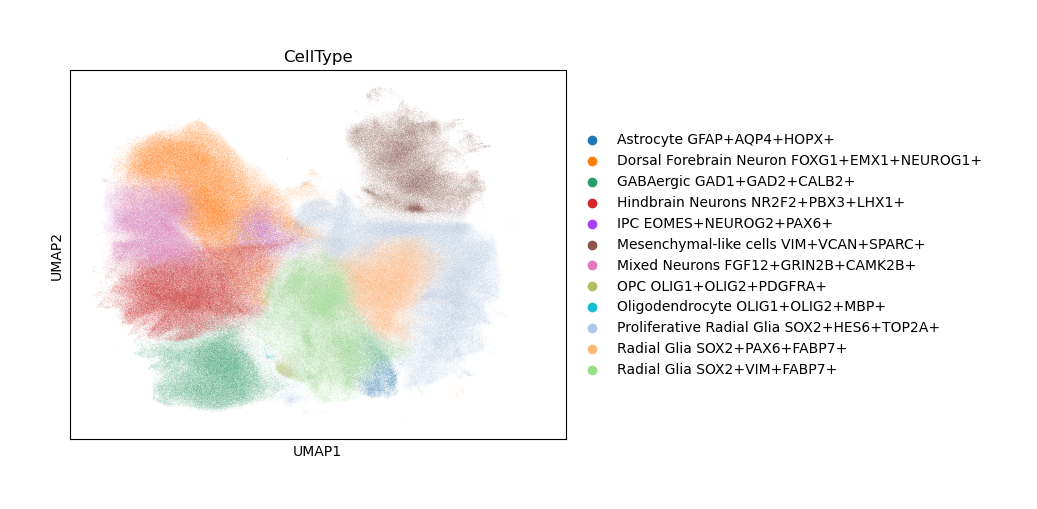

In [6]:
sc.pl.umap(adata, color='CellType')

In [7]:
## Set Up Subtype Columns ##

subclass_clusters = ['Proliferative Radial Glia SOX2+HES6+TOP2A+',
 'Radial Glia SOX2+VIM+FABP7+',
 'Radial Glia SOX2+PAX6+FABP7+',
 'IPC EOMES+NEUROG2+PAX6+',
 'Mixed Neurons FGF12+GRIN2B+CAMK2B+',
 'Hindbrain Neurons NR2F2+PBX3+LHX1+',
 'GABAergic GAD1+GAD2+CALB2+',
 'Mesenchymal-like cells VIM+VCAN+SPARC+',
 'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+',
  'OPC OLIG1+OLIG2+PDGFRA+',
 'Oligodendrocyte OLIG1+OLIG2+MBP+',
 'Astrocyte GFAP+AQP4+HOPX+']

cluster_order = []

for rel_cluster in subclass_clusters:
    cluster_order = cluster_order + adata[adata.obs['CellType'] == rel_cluster].obs['subtype_cluster_annotations_markers'].unique().tolist()

cluster_order.reverse()

In [8]:
subtype_dge_list = []
for file_path in glob.glob('/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/one_vs_all/subtypes_remerged/DE_*'):
    dge = pd.read_csv(file_path, index_col=0)
    subtype_dge_list.append(dge)

subtype_dges = pd.concat(subtype_dge_list, axis=0)

subtype_dges = subtype_dges[~pd.Series(subtype_dges.index).str.contains('ENSG').values]

subtype_cluster_dict = dict(zip(adata.obs['cluster_level_3'], adata.obs['subtype_cluster_annotations_markers']))

subtype_dges['cluster'] = subtype_dges['subtype'].map(subtype_cluster_dict)

subtype_dges['neglogP'] = -np.log10(subtype_dges['adj.P.Val'])

# Prep Plot #

plot_df = subtype_dges[['logFC', 'neglogP', 'cluster']].copy()

plot_df['gene'] = subtype_dges.index  # gene names are in index

#########

plot_df['cluster'] = pd.Categorical(plot_df['cluster'], categories=cluster_order, ordered=True)
plot_df = plot_df.sort_values(by='cluster') 

gene_order = plot_df['cluster'].str.split(' ').apply(lambda x: x[-1]).str.strip('+').str.split('+').explode().unique().tolist()

gene_order.reverse()

plot_df['gene'] = pd.Categorical(plot_df['gene'], categories=gene_order, ordered=True)

# useful genes
plot_df = plot_df[plot_df['gene'].isin(gene_order)]

In [9]:
red_blue_palette = [
    "#b2182b",
    "#d6604d",
    "#f4a582",
    "#fddbc7",
    "#f7f7f7",
    "#d1e5f0",
    "#92c5de",
    "#4393c3",
    "#2166ac"
]

red_blue_palette = red_blue_palette[::-1]

sns.color_palette(red_blue_palette, as_cmap=True)

['#2166ac',
 '#4393c3',
 '#92c5de',
 '#d1e5f0',
 '#f7f7f7',
 '#fddbc7',
 '#f4a582',
 '#d6604d',
 '#b2182b']

In [10]:
plot_df[plot_df['gene'] == 'AQP4']

,logFC,neglogP,cluster,gene
AQP4,4.048856,17.474286,Astrocyte GFAP+AQP4+HOPX+,AQP4
AQP4,0.296123,0.073684,Oligodendrocyte OLIG1+OLIG2+MBP+,AQP4
AQP4,0.080645,0.029227,OPC OLIG1+OLIG2+PDGFRA+,AQP4
AQP4,-1.213605,0.452197,Primed RG RELN+NEUROD1+DCX+,AQP4
AQP4,0.456944,0.383931,RG FABP7+PTPRZ1+EGFR+,AQP4
AQP4,0.017284,0.011991,Glioblast PTGDS+CA12+EDNRB+,AQP4
AQP4,3.048799,14.398456,CP-Primed RG TTR+FABP7+HOPX+,AQP4


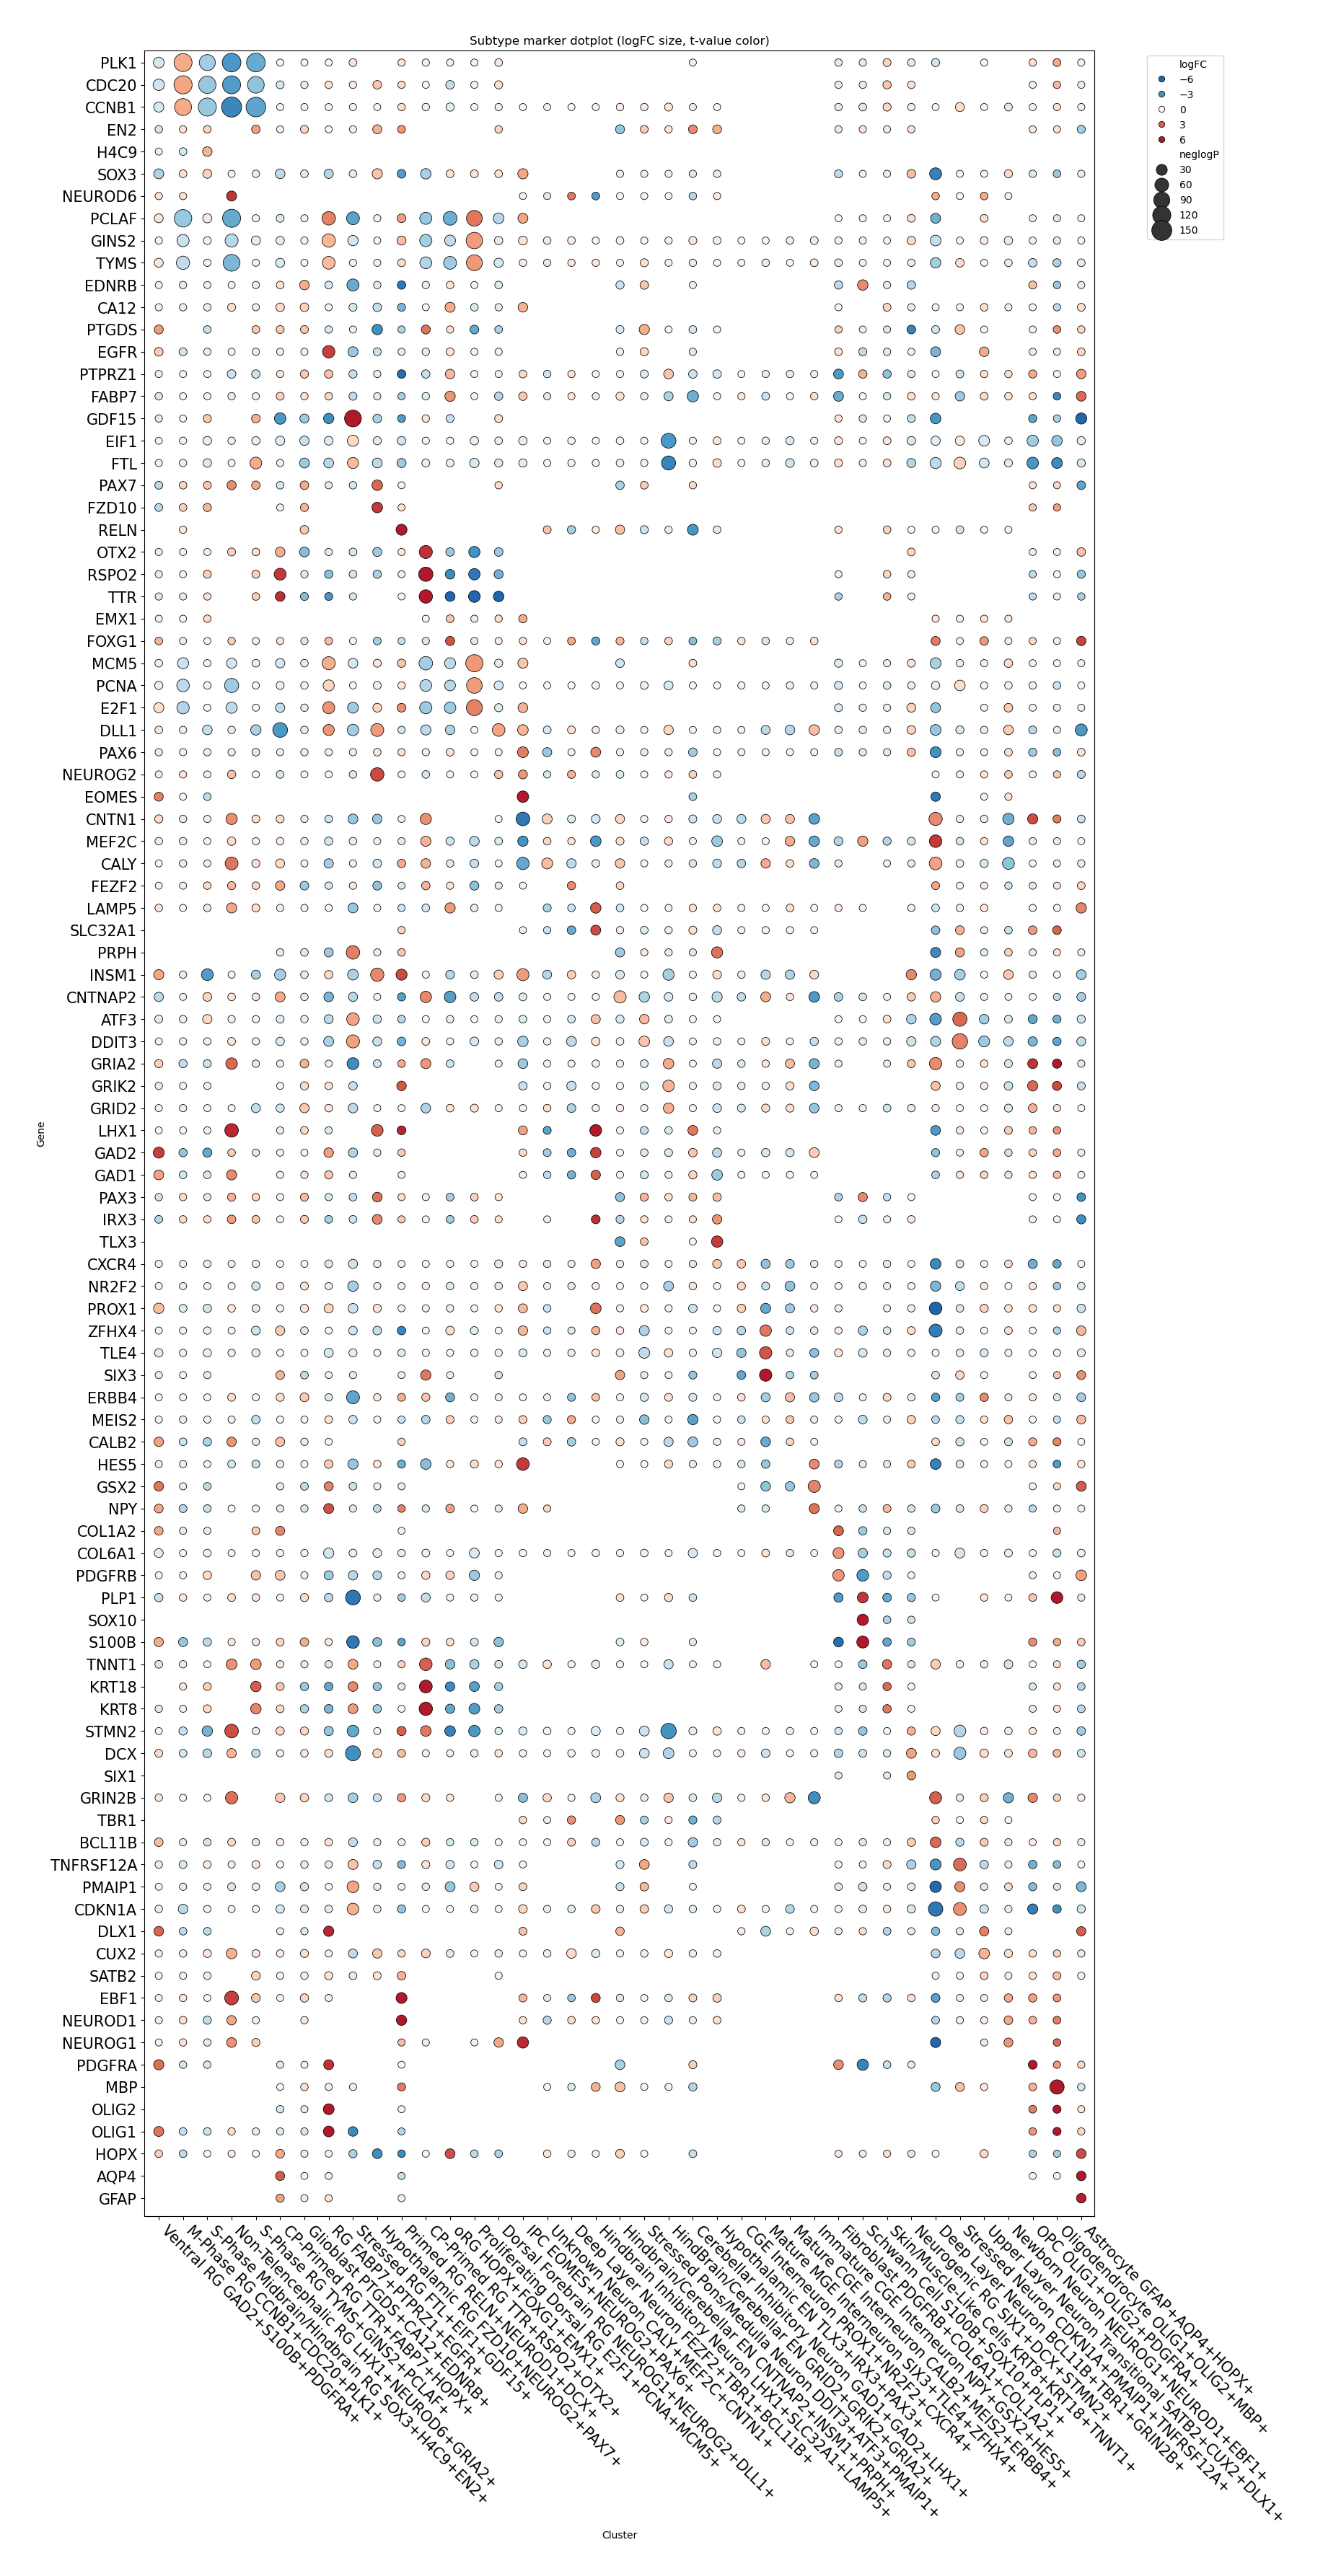

In [11]:
plt.figure(figsize=(17, 39))

custom_cmap = LinearSegmentedColormap.from_list(
    "red_blue_custom",
    red_blue_palette
)

sns.scatterplot(
    data=plot_df,
    x='cluster',
    y='gene',
    size='neglogP',
    hue='logFC',
    palette=custom_cmap,
    hue_norm=(-4, 4),
    sizes=(50, 400),
    edgecolor='black'
)

plt.xticks(rotation=-45, ha='left')
plt.xlabel("Cluster")
plt.ylabel("Gene")
plt.title("Subtype marker dotplot (logFC size, t-value color)")
plt.gca().tick_params(axis='both', labelsize=15)  # adjust size as you like
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(len(plot_df['gene'].unique()) - .2, -0.55)
plt.xlim(len(plot_df['cluster'].unique()) - 0.4, -0.55)
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_2_Composition_Subtype_Dotplot_Long.svg", dpi=500, bbox_inches="tight")
plt.show()

In [12]:
cluster_order.reverse()
gene_order.reverse()

plot_df['cluster'] = pd.Categorical(plot_df['cluster'], categories=cluster_order, ordered=True)
plot_df['gene'] = pd.Categorical(plot_df['gene'], categories=gene_order, ordered=True)

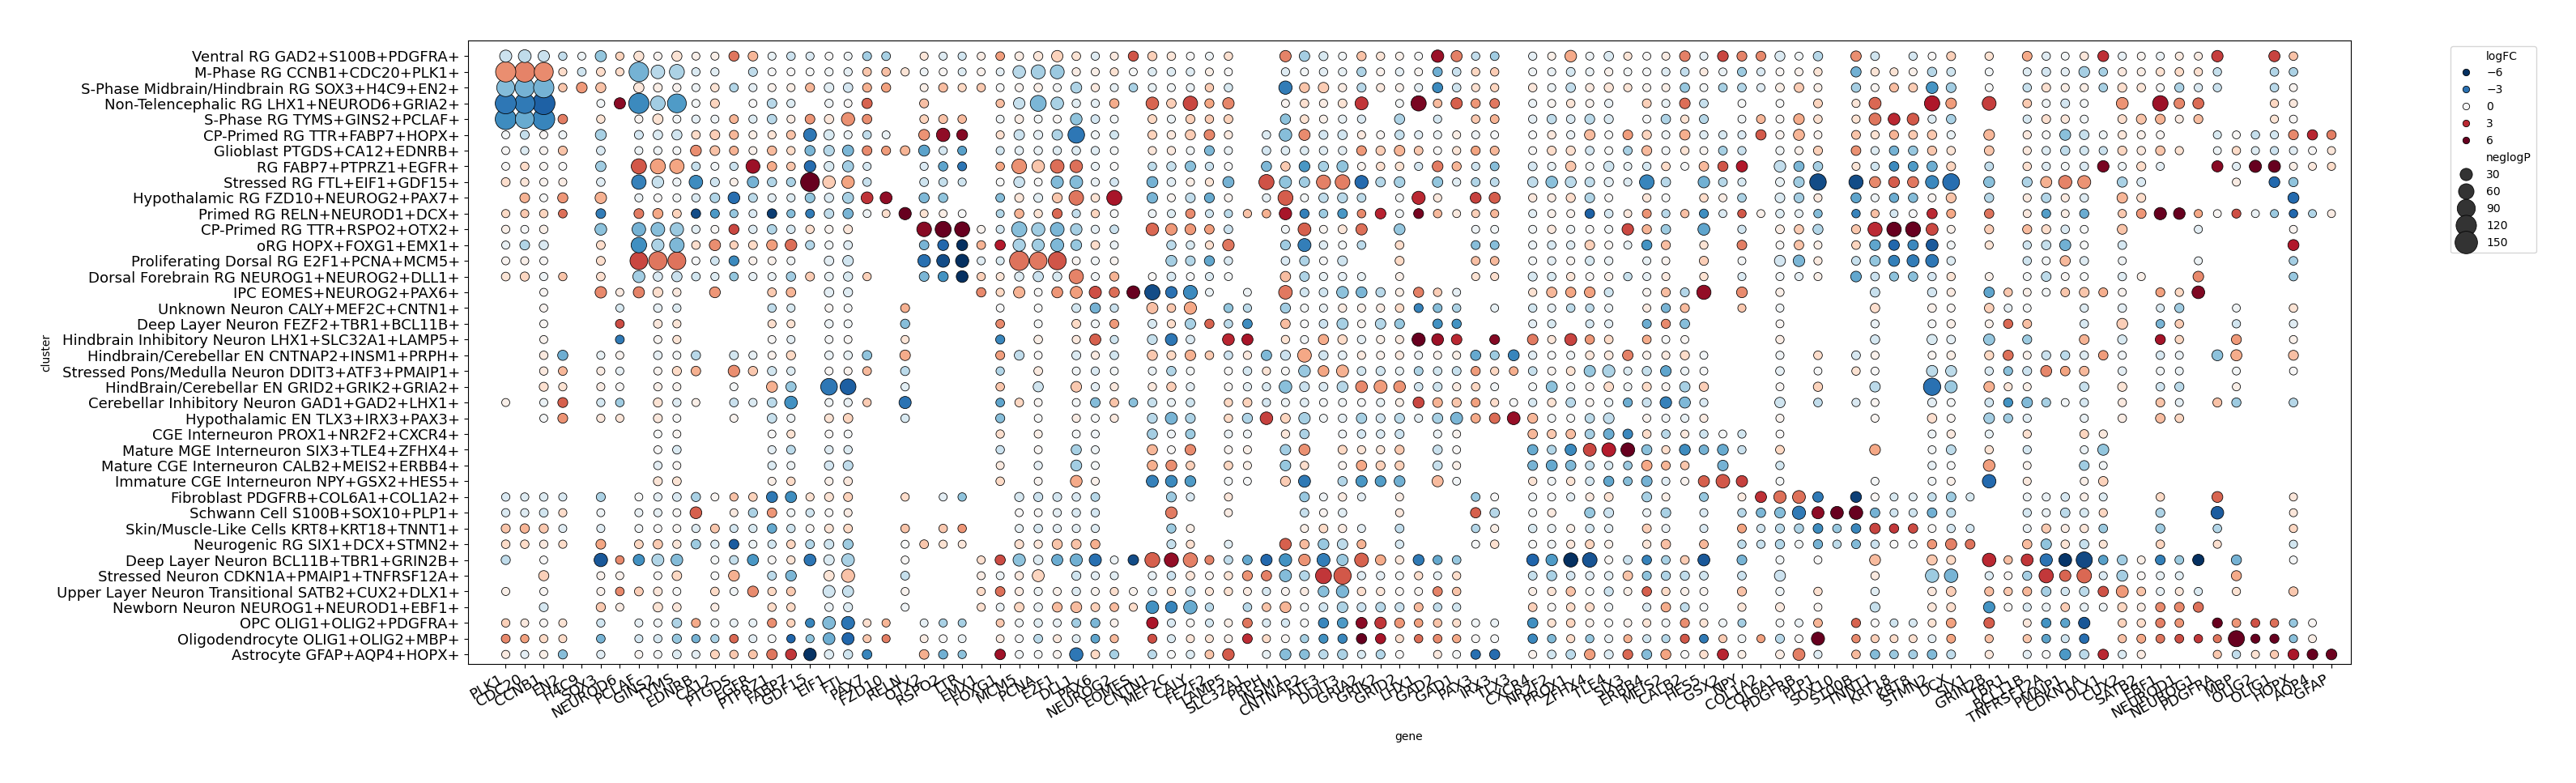

In [13]:
plt.figure(figsize=(30, 10))

sns.scatterplot(
    data=plot_df,
    y='cluster',
    x='gene',
    size='neglogP',
    hue='logFC',
    palette='RdBu_r',
    hue_norm=(-4, 4),
    sizes=(50, 400),
    edgecolor='black')

plt.xticks(rotation=30, ha='right')
plt.gca().tick_params(axis='both', labelsize=13)  # adjust size as you like
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(len(plot_df['gene'].unique()) + 1, -1)
plt.ylim(len(plot_df['cluster'].unique()) -0.4, -1)
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_2_Composition_Subtype_Dotplot_Wide.svg", dpi=500, bbox_inches="tight")
plt.show()

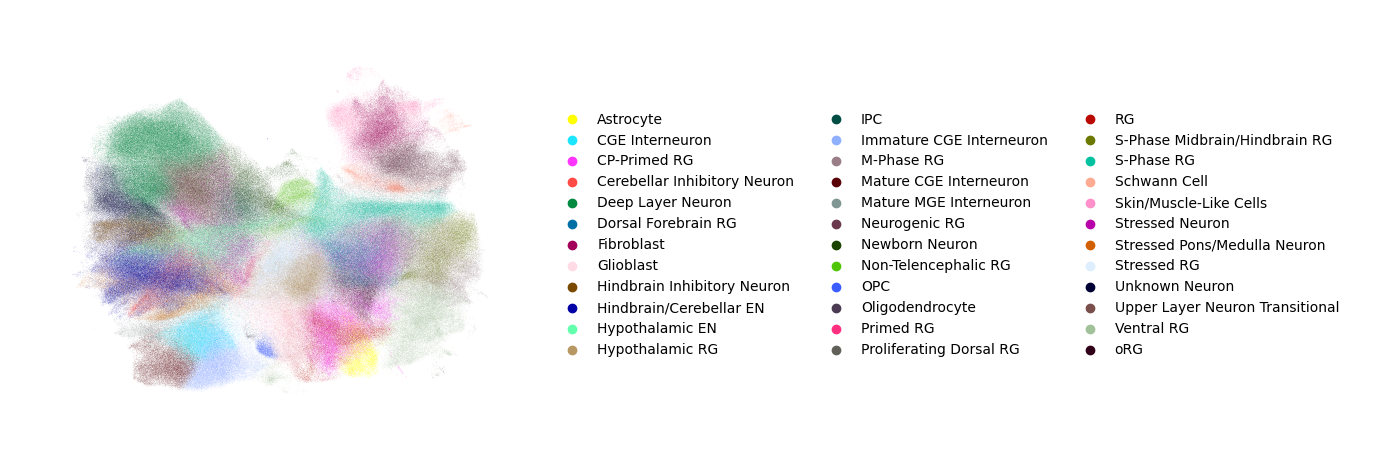

In [14]:
fig, ax = plt.subplots()

sc.pl.umap(adata, color='subtype_cluster_annotations', ax=ax, show=False)

# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Remove title
ax.set_title('')

# Remove border (spines) and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_2_Composition_Subtype_UMAP.png", dpi=500, bbox_inches="tight")

plt.show()

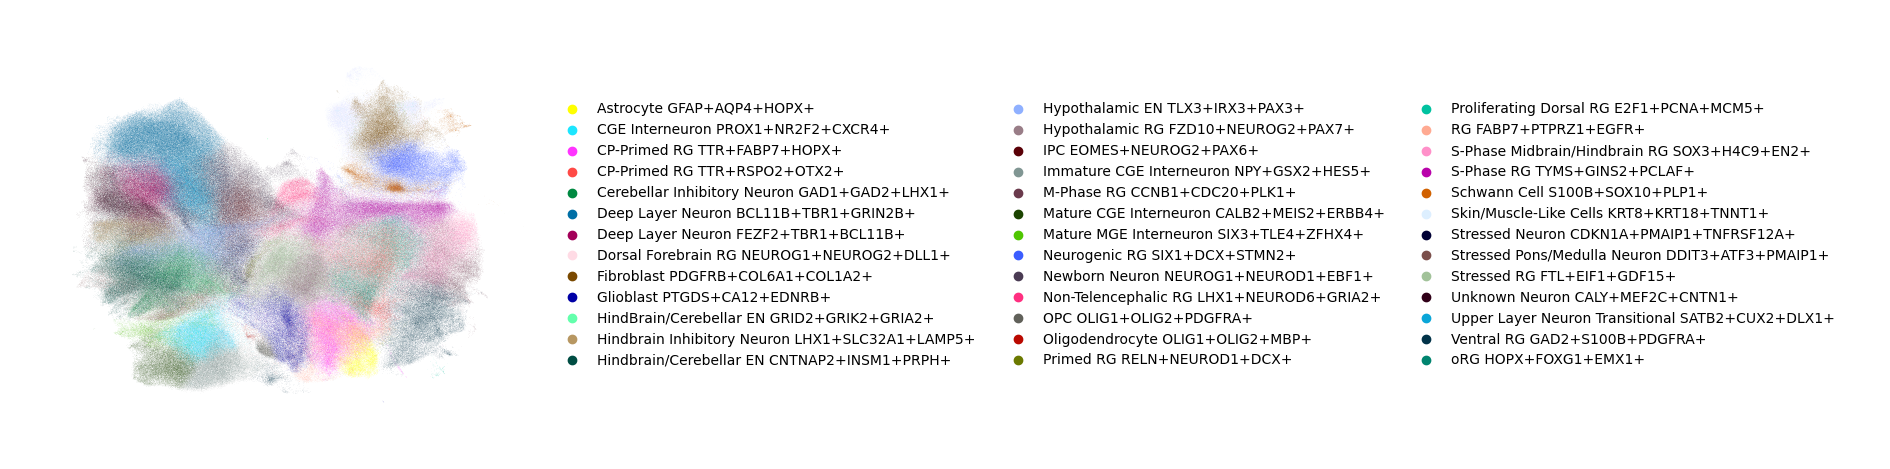

In [15]:
fig, ax = plt.subplots()

sc.pl.umap(adata, color='subtype_cluster_annotations_markers', ax=ax, show=False)

# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Remove title
ax.set_title('')

# Remove border (spines) and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_2_Composition_Subtype_UMAP_markers.png", dpi=500, bbox_inches="tight")

plt.show()

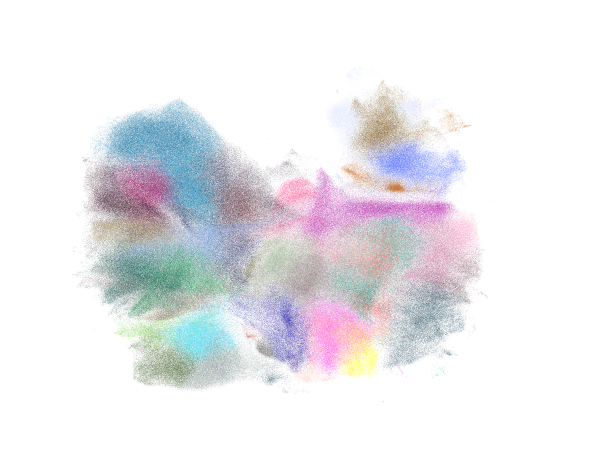

In [16]:
fig, ax = plt.subplots()

sc.pl.umap(adata, color='subtype_cluster_annotations_markers', ax=ax, show=False, legend_loc=None)

# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Remove title
ax.set_title('')

# Remove border (spines) and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_2_Composition_Subtype_UMAP_markers_no_legend.png", 
            pad_inches=0,
            transparent=True,
            dpi=500, bbox_inches="tight")


plt.show()

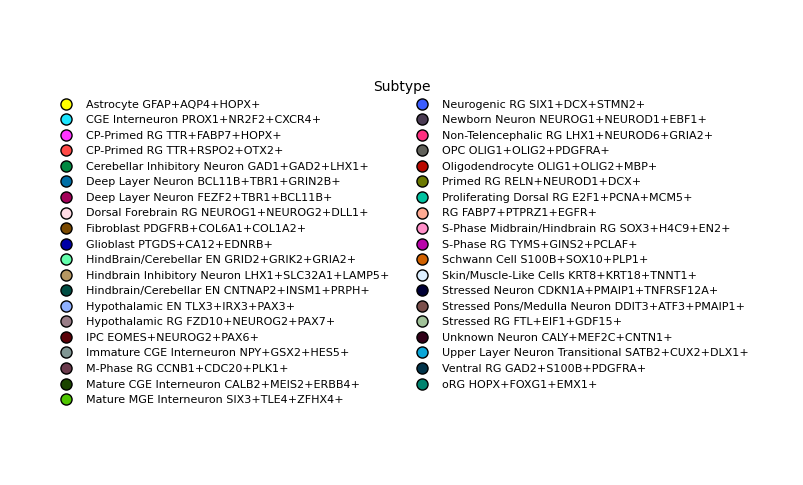

In [17]:
## UMAP ##

cats = adata.obs['subtype_cluster_annotations_markers'].cat.categories
colors = adata.uns['subtype_cluster_annotations_markers_colors']

handles = [
    Line2D([0], [0],
        marker='o',
        color='none',
        markerfacecolor=c,
        markersize=8,
        label=cat)
    for c, cat in zip(colors, cats)
]

fig, ax = plt.subplots(figsize=(3, 5))

ax.legend(
    handles=handles,
    title='Subtype',
    loc='center',
    frameon=False,
    ncol=2,
    fontsize=8,
    title_fontsize=10)

ax.axis('off')

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_2_Composition_Subtype_UMAP_legend_only.svg", 
            dpi=500, bbox_inches="tight")
plt.show()

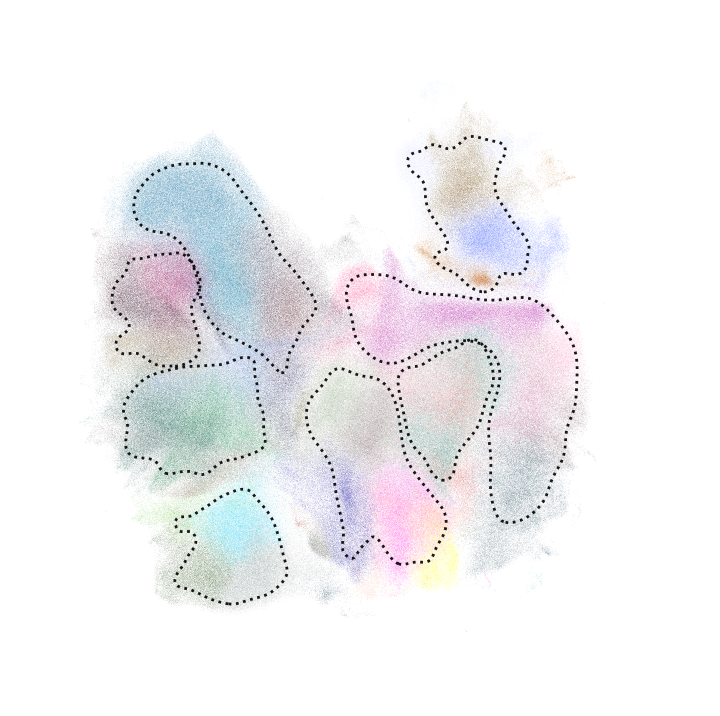

In [18]:
# Get Outlines #

fig, ax = plt.subplots(figsize=(8, 8))

# Main UMAP
sc.pl.umap(
    adata,
    color='subtype_cluster_annotations_markers',
    ax=ax,
    show=False,
    legend_loc=None
)

umap = adata.obsm["X_umap"]
groups = adata.obs["subclass_annotations_markers"]

# Max cells per subclass for KDE
MAX_POINTS = 10000

rng = np.random.default_rng(42)

for group in groups.unique():

    idx = np.where(groups == group)[0]

    # Random subsample
    if len(idx) > MAX_POINTS:
        idx = rng.choice(idx, MAX_POINTS, replace=False)

    x = umap[idx, 0]
    y = umap[idx, 1]

    sns.kdeplot(
        x=x,
        y=y,
        ax=ax,
        levels=[0.35],
        color='black',
        linewidths=2,
        linestyles=':',
        fill=False,
        alpha=0.9
    )

# Cleanup
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.show()

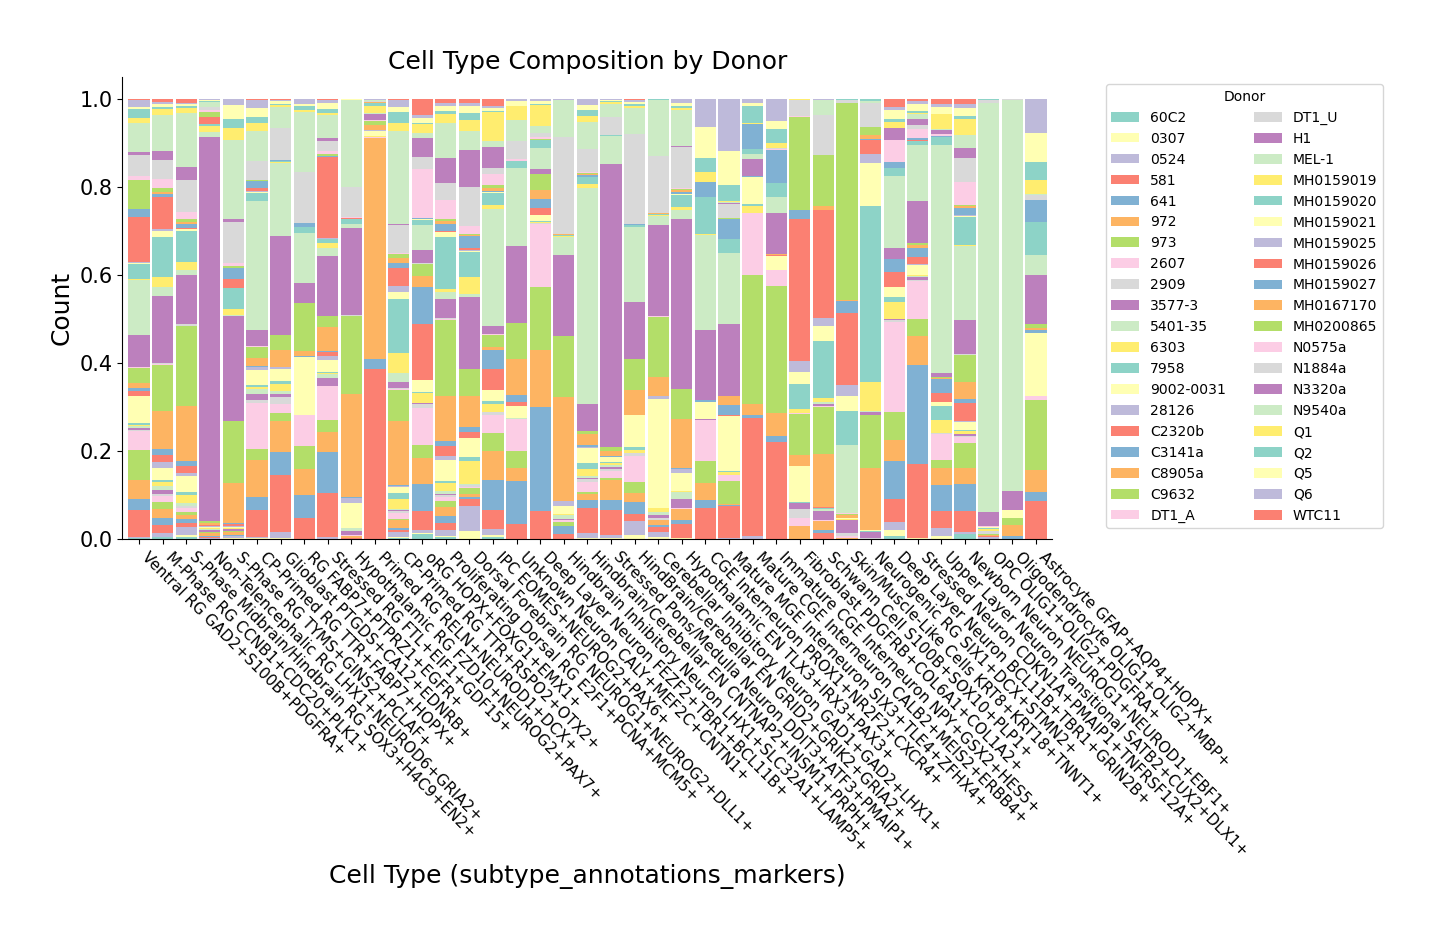

In [19]:
# Create a contingency table (counts of each subclass_annotations_markers per Donor)
contingency_table = pd.crosstab(adata.obs['subtype_cluster_annotations_markers'], adata.obs['Donor'])

# Create a color palette with a distinct color for each donor
unique_donors = adata.obs['Donor'].unique()
palette = sns.color_palette("Set3", len(unique_donors))

# Plot a stacked barplot with a taller and skinnier figure
fig, ax = plt.subplots(figsize=(12, 6))  # Increase height, reduce width

# Plot the contingency table as a stacked barplot

# normalize
contingency_table = contingency_table.divide(contingency_table.sum(axis=1), axis=0)

# order table
contingency_table = contingency_table.loc[cluster_order]

# plot
contingency_table.plot(kind='bar', stacked=True, color=palette, ax=ax,  width=0.9)

# Set plot labels and title
ax.set_xlabel('Cell Type (subtype_annotations_markers)', fontsize=18)
ax.set_ylabel('Count', fontsize=18)
ax.set_title('Cell Type Composition by Donor', fontsize=18)

# Rotate the x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha='left')

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# fontsizes
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=15)

# Move legend outside the plot and set multiple columns for better readability
ax.legend(title='Donor', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)

# Savefig
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_2_Composition_Subtype_By_Donor_Table.svg", dpi=500, bbox_inches="tight")

# Show plot
plt.show()

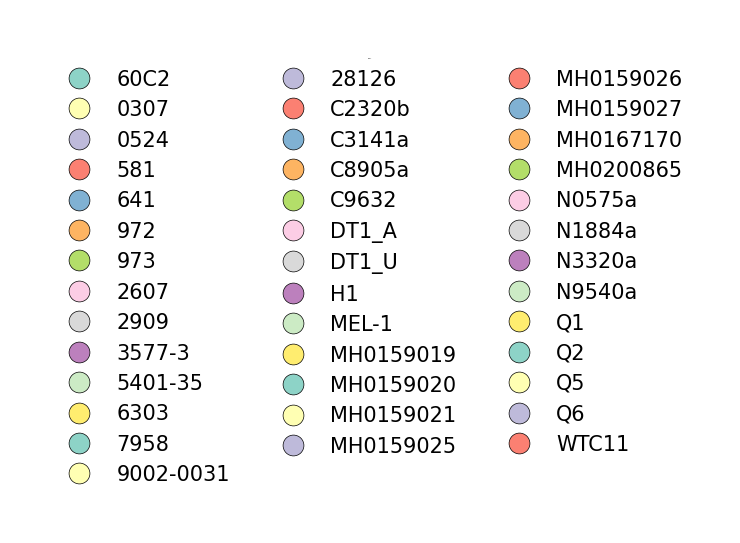

In [20]:
## Subtype Legend ##

donors = contingency_table.columns  # same order as plotted
colors = palette

handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        markerfacecolor=c,
        markeredgecolor='black',   # helps visibility
        markeredgewidth=0.5,
        markersize=15,
        label=donor
    )
    for donor, c in zip(donors, colors)
]

fig_legend, ax_legend = plt.subplots(figsize=(3, 3))  # tall for many donors

ax_legend.legend(
    handles=handles,
    title='Donor',
    loc='center',
    frameon=False,
    ncol=3,              # try 2–3 depending on density
    fontsize=15,
    title_fontsize=0)

ax_legend.axis('off')

plt.savefig(
    "/home/deepak/datasets/scz_meta_analysis/panels/Fig_2_Composition_Subtype_By_Donors_Legend_Only.svg",
    dpi=500,
    bbox_inches="tight"
)

plt.show()

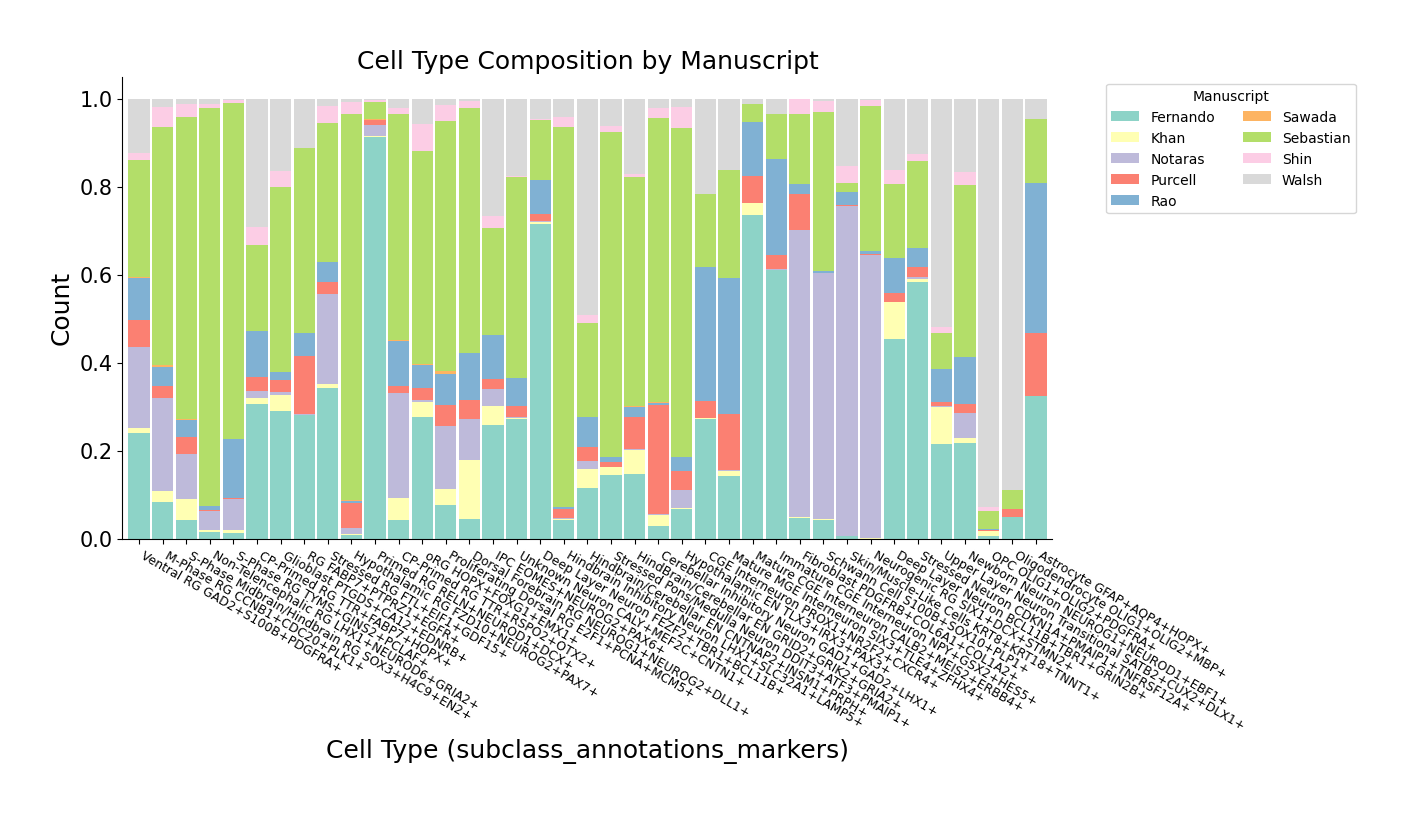

In [21]:
# Create a contingency table (counts of each subclass_annotations_markers per Manuscript)
contingency_table = pd.crosstab(adata.obs['subtype_cluster_annotations_markers'], adata.obs['Manuscript'])

# Create a color palette with a distinct color for each Manuscript
unique_manuscripts = adata.obs['Manuscript'].unique()
palette = sns.color_palette("Set3", len(unique_manuscripts))

# Plot a stacked barplot with adjusted bar width and figure size
fig, ax = plt.subplots(figsize=(12, 6))  # Taller figure
contingency_table = contingency_table.divide(contingency_table.sum(axis=1), axis=0)

# order table
contingency_table = contingency_table.loc[cluster_order]

# plot
contingency_table.plot(kind='bar', stacked=True, color=palette, ax=ax, width=0.9)

# Set plot labels and title
ax.set_xlabel('Cell Type (subclass_annotations_markers)', fontsize=18)
ax.set_ylabel('Count', fontsize=18)
ax.set_title('Cell Type Composition by Manuscript', fontsize=18)

# Rotate the x-axis labels 45 degrees and align them to the right
ax.set_xticklabels(ax.get_xticklabels(), rotation=-30, ha='left')

# Move legend outside the plot and set multiple columns for better readability
ax.legend(title='Manuscript', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# fontsizes
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=15)

# Savefig
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_2_Composition_Subtype_By_Manuscript_Table.svg", 
            dpi=500, bbox_inches="tight")

# Show plot
plt.show()

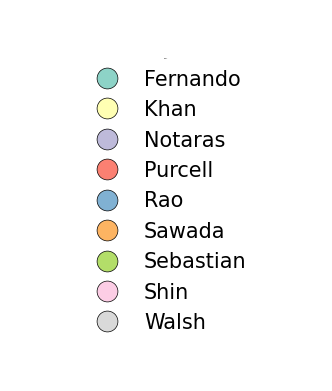

In [22]:
manuscripts = contingency_table.columns  # same order as plotted
colors = palette

handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        markerfacecolor=c,
        markeredgecolor='black',   # helps visibility
        markeredgewidth=0.5,
        markersize=15,
        label=donor
    )
    for donor, c in zip(manuscripts, colors)
]

fig_legend, ax_legend = plt.subplots(figsize=(3, 3))  # tall for many manuscripts

ax_legend.legend(
    handles=handles,
    title='Donor',
    loc='center',
    frameon=False,
    ncol=1,              # try 2–3 depending on density
    fontsize=15,
    title_fontsize=0)

ax_legend.axis('off')

plt.savefig(
    "/home/deepak/datasets/scz_meta_analysis/panels/Fig_2_Composition_Subtype_By_Manuscript_Legend_Only.svg",
    dpi=500,
    bbox_inches="tight"
)

plt.show()

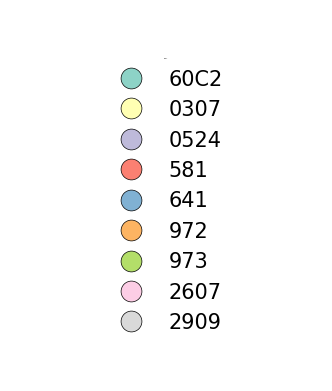

In [23]:
manuscripts = contingency_table.columns  # same order as plotted
colors = palette

handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        markerfacecolor=c,
        markeredgecolor='black',   # helps visibility
        markeredgewidth=0.5,
        markersize=15,
        label=donor
    )
    for donor, c in zip(donors, colors)
]

fig_legend, ax_legend = plt.subplots(figsize=(3, 3))  # tall for many manuscripts

ax_legend.legend(
    handles=handles,
    title='Donor',
    loc='center',
    frameon=False,
    ncol=1,              # try 2–3 depending on density
    fontsize=15,
    title_fontsize=0)

ax_legend.axis('off')

plt.savefig(
    "/home/deepak/datasets/scz_meta_analysis/panels/Fig_2_Composition_Subtype_By_Manuscripts_Legend_Only.svg",
    dpi=500,
    bbox_inches="tight"
)

plt.show()

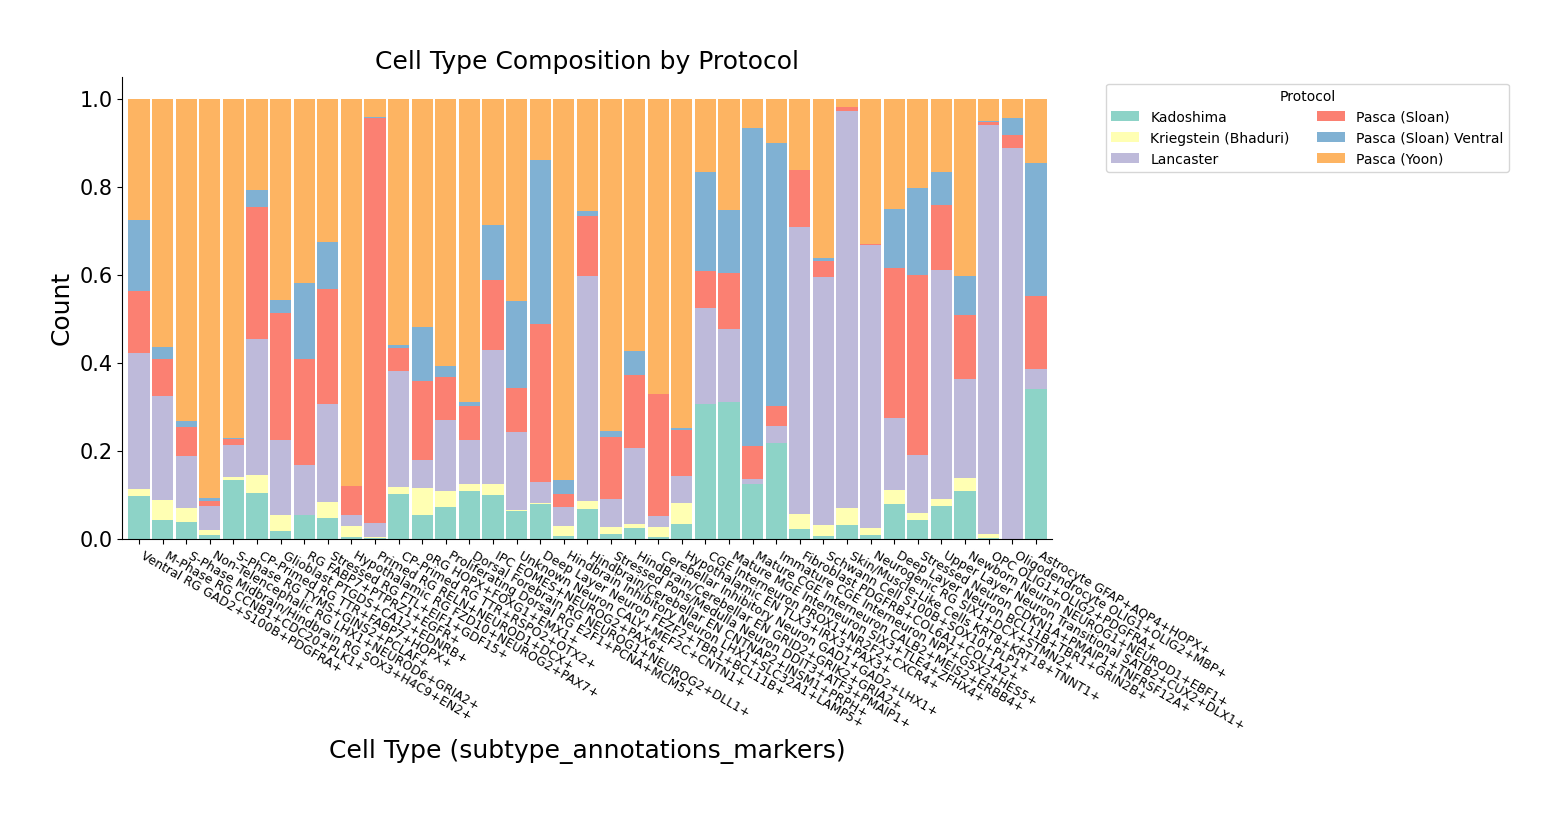

In [24]:
# Create a contingency table (counts of each subclass_annotations_markers per Protocol)
contingency_table = pd.crosstab(adata.obs['subtype_cluster_annotations_markers'], adata.obs['Protocol'])

# Create a color palette with a distinct color for each Protocol
unique_protocols = adata.obs['Protocol'].unique()
palette = sns.color_palette("Set3", len(unique_protocols))

# Plot a stacked barplot with adjusted bar width and figure size
fig, ax = plt.subplots(figsize=(12, 6))  # Taller figure
contingency_table = contingency_table.divide(contingency_table.sum(axis=1), axis=0)

# order table
contingency_table = contingency_table.loc[cluster_order]

# plot
contingency_table.plot(kind='bar', stacked=True, color=palette, ax=ax, width=0.9)

# Set plot labels and title
ax.set_xlabel('Cell Type (subtype_annotations_markers)', fontsize=18)
ax.set_ylabel('Count', fontsize=18)
ax.set_title('Cell Type Composition by Protocol', fontsize=18)

# Rotate the x-axis labels 45 degrees and align them to the right
ax.set_xticklabels(ax.get_xticklabels(), rotation=-30, ha='left')

# Move legend outside the plot and set multiple columns for better readability
ax.legend(title='Protocol', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# font sizes
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=15)

# Adjust layout to make space for the legend
# plt.tight_layout()

# Savefig
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_2_Composition_Subtype_By_Protocol_Table.svg", 
            dpi=500, bbox_inches="tight")

# Show plot
plt.show()

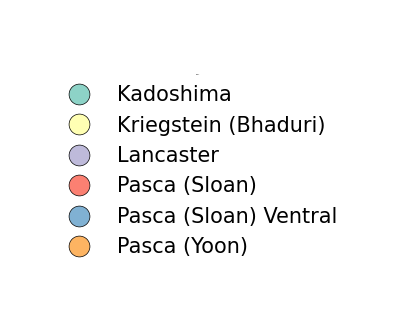

In [25]:
protocols = contingency_table.columns  # same order as plotted
colors = palette

handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        markerfacecolor=c,
        markeredgecolor='black',   # helps visibility
        markeredgewidth=0.5,
        markersize=15,
        label=donor
    )
    for donor, c in zip(protocols, colors)
]

fig_legend, ax_legend = plt.subplots(figsize=(3, 3))  # tall for many protocols

ax_legend.legend(
    handles=handles,
    title='Donor',
    loc='center',
    frameon=False,
    ncol=1,              # try 2–3 depending on density
    fontsize=15,
    title_fontsize=0)

ax_legend.axis('off')

plt.savefig(
    "/home/deepak/datasets/scz_meta_analysis/panels/Fig_2_Composition_Subtype_By_Protocol_Legend_Only.svg",
    dpi=500,
    bbox_inches="tight"
)

plt.show()

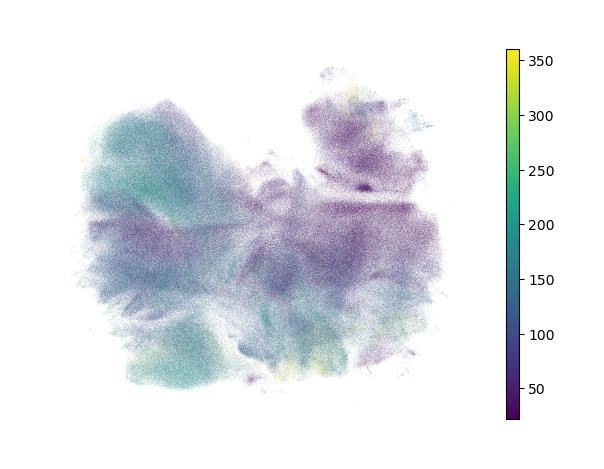

In [26]:
fig, ax = plt.subplots()

sc.pl.umap(adata, color='Day', ax=ax, show=False)

# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Remove title
ax.set_title('')

# Remove border (spines) and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_2_UMAP_By_Day.png", 
            dpi=500, bbox_inches="tight")

plt.show()

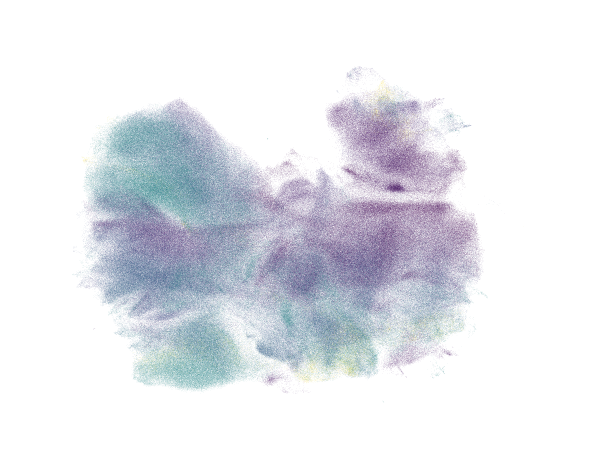

In [27]:
fig, ax = plt.subplots()

sc.pl.umap(adata, color='Day', ax=ax, show=False, colorbar_loc=None)

# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Remove title
ax.set_title('')

# Remove border (spines) and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_2_UMAP_By_Day_no_Legend.png", 
            dpi=500, bbox_inches="tight")

plt.show()

/tmp/ipykernel_253263/3474735249.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


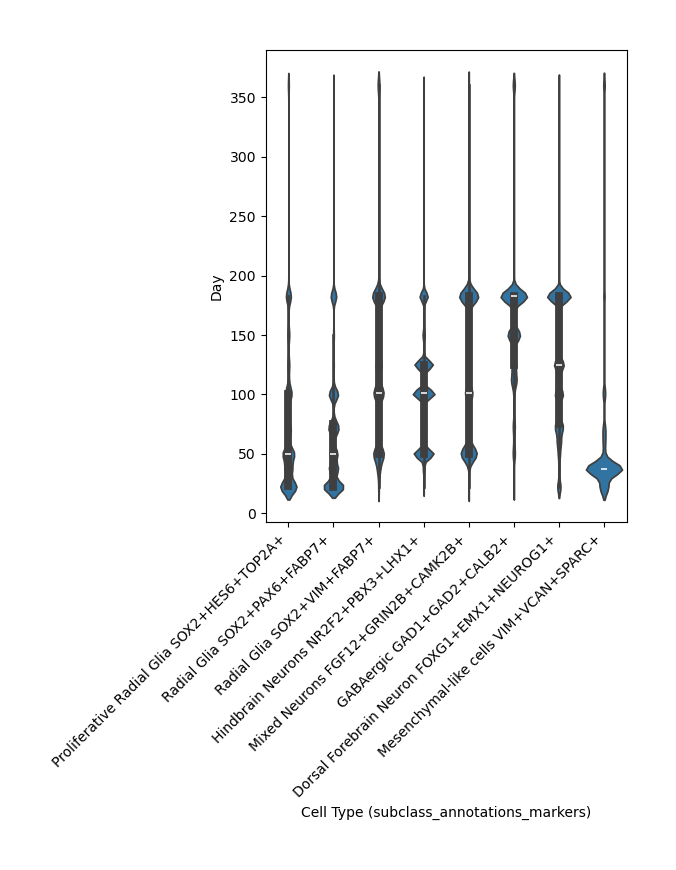

In [28]:
fig, ax = plt.subplots(figsize=(6, 8))  # width, height

# Create the violin plot
sns.violinplot(data=adata.obs, x='subclass_annotations_markers', y='Day', ax=ax)

# Rotate x-axis labels and set horizontal alignment
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Set plot labels and title (optional, for better readability)
ax.set_xlabel('Cell Type (subclass_annotations_markers)')
ax.set_ylabel('Day')

# Show plot
plt.tight_layout()
plt.show()

/tmp/ipykernel_253263/1139319225.py:25: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_253263/1139319225.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


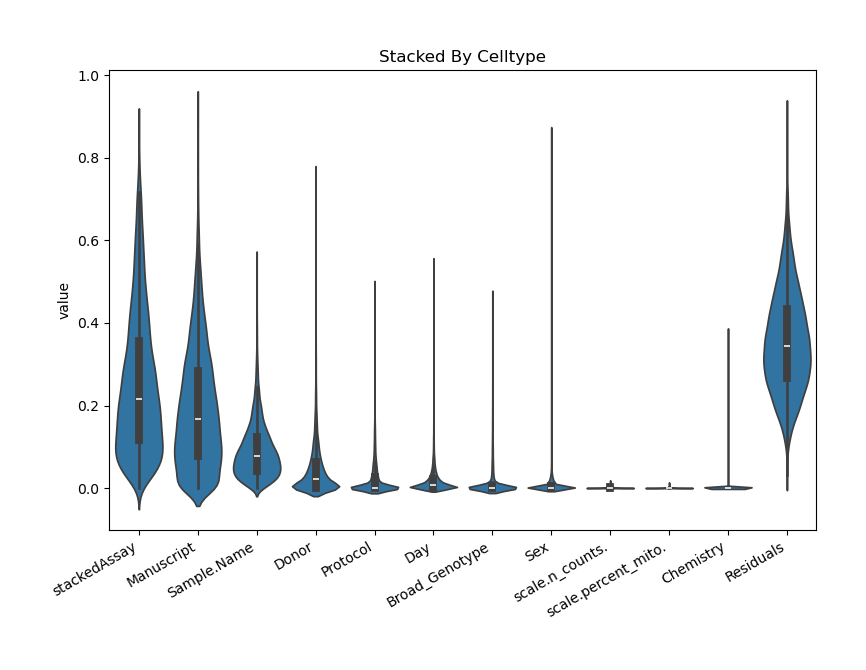

In [29]:
## Variance Partition ##

## generally and for mixing ##
DREAMLET_PATH = '/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/disease_analyses/'
stacked_df = pd.read_csv(Path(DREAMLET_PATH) / 'variance_partition_long_stacked.csv')

vp_adaptive_melted = pd.melt(stacked_df, id_vars='gene')

vp_adaptive_melted = vp_adaptive_melted[vp_adaptive_melted['variable'] != 'assay']

# Step 1: Compute mean values (excluding 'residuals')
means = (
    vp_adaptive_melted[vp_adaptive_melted['variable'] != 'Residuals']
    .groupby('variable')['value']
    .mean()
    .sort_values(ascending=False)
)

# Step 2: Create new order: sorted variables + 'residuals' at the end
new_order = list(means.index) + ['Residuals']

# Step 3: Plot with ordered categories
fig, ax = plt.subplots(figsize=(8, 6))
plt.title('Stacked By Celltype')
sns.violinplot(
    data=vp_adaptive_melted,
    x='variable',
    y='value',
    scale='width',
    order=new_order,
    ax=ax
)
plt.xlabel('')

# Step 4: Rotate and align tick labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

/tmp/ipykernel_253263/3987514323.py:26: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_253263/3987514323.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


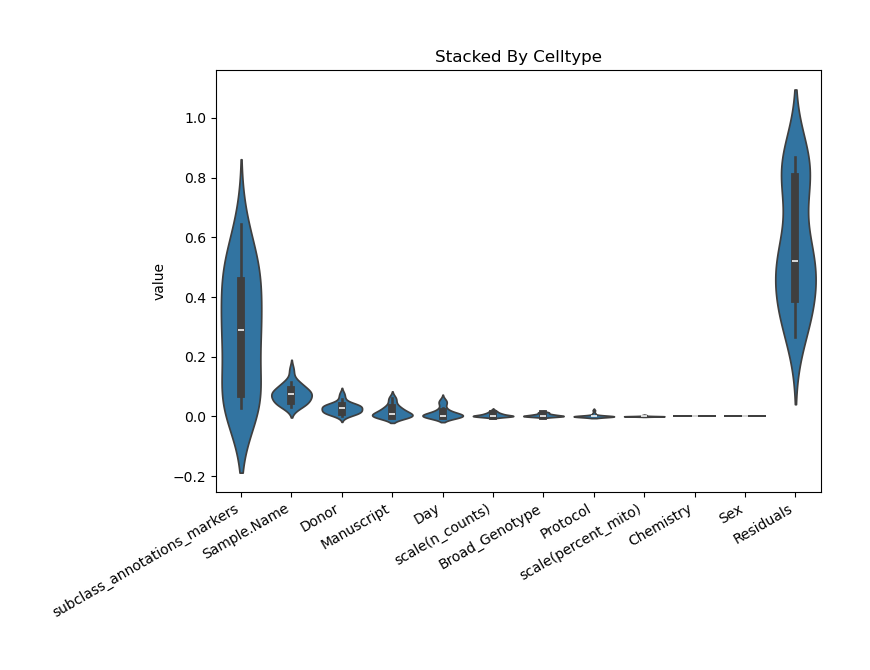

In [30]:
## Variance Partition ##

## generally and for mixing ##
DREAMLET_PATH = '/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/disease_analyses/'
stacked_df = pd.read_csv(Path(DREAMLET_PATH) / 'scvi_space_variance_partition_long.csv')

stacked_df['latent_dim'] = pd.Series(np.arange(0,20))
vp_adaptive_melted = pd.melt(stacked_df, id_vars='latent_dim')

vp_adaptive_melted = vp_adaptive_melted[vp_adaptive_melted['variable'] != 'assay']

# Step 1: Compute mean values (excluding 'residuals')
means = (
    vp_adaptive_melted[vp_adaptive_melted['variable'] != 'Residuals']
    .groupby('variable')['value']
    .mean()
    .sort_values(ascending=False)
)

# Step 2: Create new order: sorted variables + 'residuals' at the end
new_order = list(means.index) + ['Residuals']

# Step 3: Plot with ordered categories
fig, ax = plt.subplots(figsize=(8, 6))
plt.title('Stacked By Celltype')
sns.violinplot(
    data=vp_adaptive_melted,
    x='variable',
    y='value',
    scale='width',
    order=new_order,
    ax=ax
)
plt.xlabel('')

# Step 4: Rotate and align tick labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

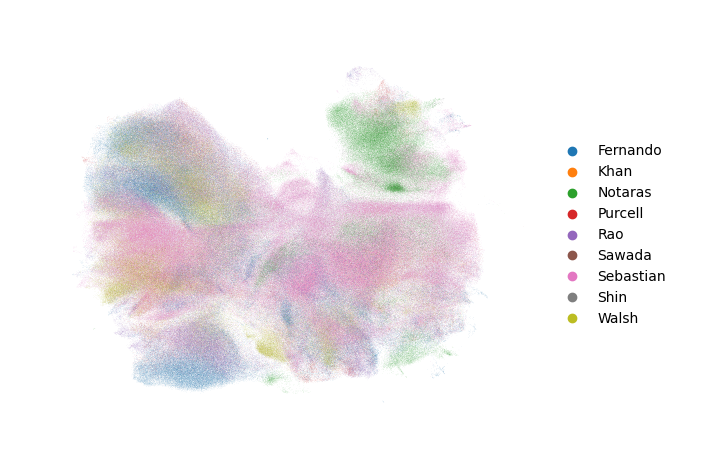

In [31]:
fig, ax = plt.subplots()

sc.pl.umap(adata, color='Manuscript', ax=ax, show=False)

# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Remove title
ax.set_title('')

# Remove border (spines) and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.show()

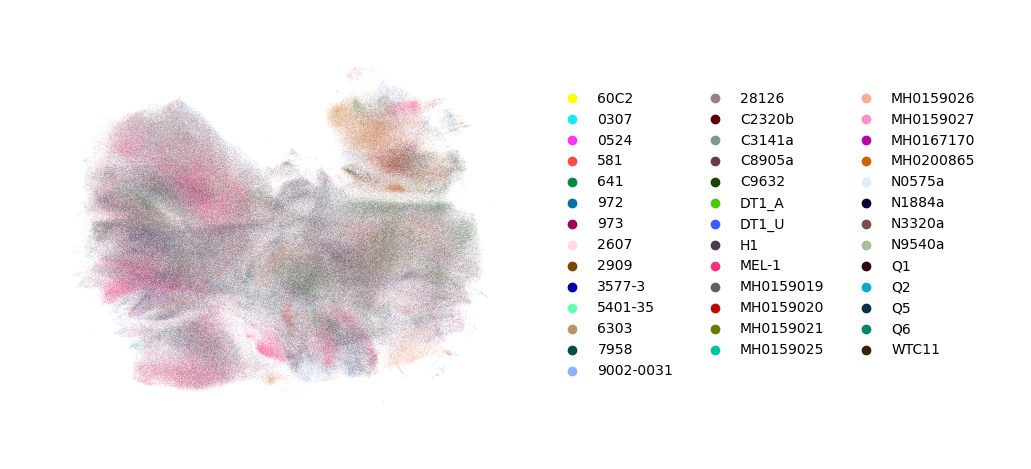

In [32]:
fig, ax = plt.subplots()

sc.pl.umap(adata, color='Donor', ax=ax, show=False)

# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Remove title
ax.set_title('')

# Remove border (spines) and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.show()

In [33]:
subtype_numbers = pd.DataFrame(adata.obs['subtype_cluster_annotations_markers'].value_counts())

subtype_numbers = subtype_numbers.reset_index(drop=False)

subtype_numbers['subtype_cluster_annotations_markers'] = pd.Categorical(subtype_numbers['subtype_cluster_annotations_markers'], 
                                                                        ordered=True,
                                                                        categories=cluster_order)

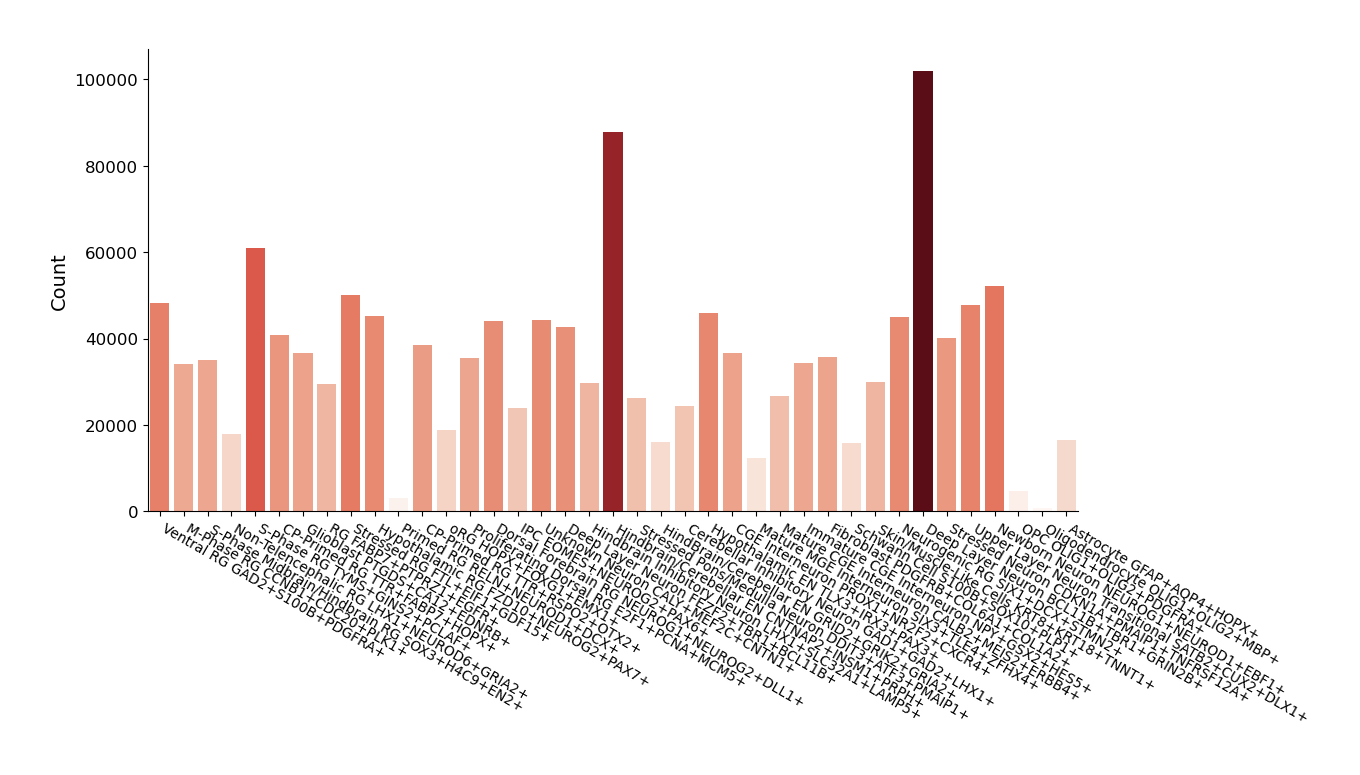

In [34]:
fig = plt.figure(figsize=(12, 6))

ax = sns.barplot(data=subtype_numbers, x='subtype_cluster_annotations_markers', 
                 y='count',  hue='count',  palette='Reds', legend=False)

# Rotate + control tick label font sizes
plt.xticks(rotation=-30, ha='left', fontsize=10)
plt.yticks(fontsize=12)

# Axis label font sizes
ax.set_xlabel('', fontsize=14)
ax.set_ylabel('Count', fontsize=14)

# Optional title
# ax.set_title('Subtype Counts', fontsize=16)

# Despine
sns.despine()

# Savefig
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_2_Barplot_Counts.svg", dpi=500, bbox_inches="tight")

plt.show()